In [1]:
# Setup for Google Colab
import sys, os
if 'google.colab' in sys.modules:
    if not os.path.exists('dl_course'):
        !git clone -q --depth 1 https://github.com/konstantin-schekotihin/dl_course.git
    %cd -q /content/dl_course/02_ML
    !pip install -q torch-geometric wandb

# some initialization stuff
%run ../init.py
%matplotlib inline

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
import statsmodels.api as sm

<IPython.core.display.Latex object>

<center>
    <img src="https://raw.githubusercontent.com/konstantin-schekotihin/dl_course/master/02_ML/images/slide4.png" width="60%"/>
</center>

# Logistic Regression

## Predicting qualitative variables
- Assume we want to apply linear regression to make predictions for a qualitative binary variable 

$$ \rvar{y}=\left\{
                \begin{array}{ll}
                0 & \text{for No} \\
                1 & \text{for Yes}
                \end{array}
              \right.$$
              
- Can we simply perform a linear regression of $\rvar{y}$ on X and classify as "Yes" if $\hat{\rvar{y}} > 0.5$?
- Actually, linear regression does a good job as a classifier
    + Equivalent to linear discriminant analysis

## Example: Card balance

- Consider a simulated data set containing information on ten thousand customers 
- The aim here is to predict which customers will default on their credit card debt given
    + factors *default* and *student* with levels $[\mathit{Yes},\mathit{No}]$
    + *balance*: the average balance that the customer has remaining on their credit card after making their monthly payment
    + *income*: income of customer 

In [2]:
data = pd.read_csv('data/Default.csv')
data = data.drop(data.columns[0], axis=1)
data.describe(include='all')

,default,student,balance,income
count,10000,10000,10000.000000,10000.000000
unique,2,2,NaN,NaN
top,No,No,NaN,NaN
freq,9667,7056,NaN,NaN
mean,NaN,NaN,835.374886,33516.981876
std,NaN,NaN,483.714985,13336.639563
min,NaN,NaN,0.000000,771.967729
25%,NaN,NaN,481.731105,21340.462903
50%,NaN,NaN,823.636973,34552.644802
75%,NaN,NaN,1166.308386,43807.729272


In [3]:
data.head(10)

,default,student,balance,income
0,No,No,729.526495,44361.625074
1,No,Yes,817.180407,12106.134700
2,No,No,1073.549164,31767.138947
3,No,No,529.250605,35704.493935
4,No,No,785.655883,38463.495879
5,No,Yes,919.588530,7491.558572
6,No,No,825.513331,24905.226578
7,No,Yes,808.667504,17600.451344
8,No,No,1161.057854,37468.529288
9,No,No,0.000000,29275.268293


In [4]:
# Label encoder for class labels

le = LabelEncoder()
y = le.fit_transform(data.default)
print(le.classes_, y)

['No' 'Yes'] [0 0 0 ... 0 0 0]


In [5]:
std = StandardScaler()
X = std.fit_transform(data[['balance']])
print('Features: ', std.feature_names_in_, '\nMeans: ', std.mean_, '\nStd. deviations :', std.scale_)

Features:  ['balance'] 
Means:  [835.37488561] 
Std. deviations : [483.69079885]


## Example: Card balance
- Classification of the Default data set using *linear* and *logistic* regression

In [6]:
def plot_pred(predict):
    l = np.linspace(-5, 5, num=100).reshape(-1,1)
    plt.figure(figsize=(10,10))
    plt.scatter(X, y)
    plt.plot(l, predict(l), 'r')
    plt.show()

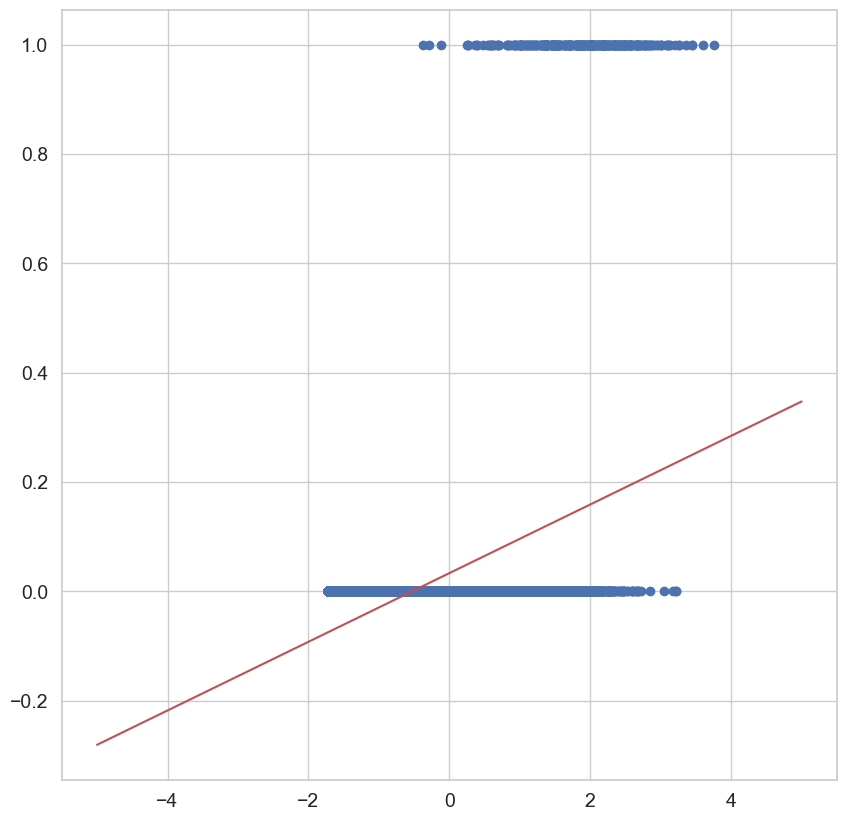

In [7]:
lin_model = LinearRegression().fit(X, y)
plot_pred(lin_model.predict)

## Issues with the linear approach

- However, linear regression might produce values that might be hard to interpret
    - The goal is not to predict a value, but to separate the examples

- In might be better to predict **probabilities** instead of arbitrary values
- However, also in this case for unlimited range of *balance* we can still get $P(\rvar{default}=1)<0$ or $P(\rvar{default}=1)>1$, since
$$P(\rvar{default}=1)=w_0+w_1\rvar{balance}$$
- **Idea**: Forward result of the linear regression model in a function $f: \mathbb{R} \mapsto [0,1]$
$$P(\rvar{default}=1)=f(w_0+w_1\rvar{balance})$$

## Logistic regression
- We have to compute the probability using a function with range $[0,1]$
- There are many such functions: step function (hardlim), sigmoid, scaled hyperbolic tangent, etc. 

- Logistic regression uses the *sigmoid function* (aka *logistic function*)

$$\sigma(x)=\frac{e^x}{1+e^{x}}$$

- Given that linear regression in our case is defined as $f(x) = w_0 + w_1 x$, the substitution results in

$$\sigma(f(x))=\frac{e^{f(x)}}{1+e^{f(x)}} = \frac{e^{w_0 + w_1 x}}{1+e^{w_0 + w_1 x}}$$

### Maximum Likelihood estimation

- We try to find $\hat w_0$ and $\hat w_1$ such that plugged in the logistic function above yield $~1$ for defaulted individuals and $~0$ otherwise
- Coefficients are estimated using the **maximum likelihood** method instead of (non-linear) least squares
- The estimates $\hat w_0$ and $\hat w_1$ are chosen to *maximize* the likelihood function, 
  - $b_i,b_j \in \vec{balance}$ are independent observations of the balance and $\sigma$ is the sigmoid function
  - Since the classification is binary, we can assume that it follows Bernoulli distribution with a parameter $p$ estimated by function $s(x)$

$$L(w_0, w_1 \mid \vec{balance})=\prod_{i:y_i=1}{\sigma(b_i)}\prod_{j:y_j=0}{(1-\sigma(b_j))}$$

### Optimization problem

- Since Likelihood is a positive function (product of positive numbers), we can use the Log-likelihood

$$l(w_0, w_1 \mid \vec{balance})=\ln[L(w_0, w_1 \mid \vec{balance})]$$

$$
=\sum_{i:y_i=1}{\ln[\sigma(b_i)]}+\sum_{j:y_j=0}{\ln[(1-\sigma(b_j)])}$$

- In practice, the optimization problem is defined as the minimization of the **negative log-likelihood**

$$\min -\sum_{y_i \in \vec{y}}{ -\ln[\sigma(b_i)] \cdot y_i - \ln[(1-\sigma(b_j)](1-y_i)}$$

- Solution of this problem can be found by gradient descent

    - Note that this problem is equivalent to optimizing the cross-entropy, $p=\sigma(x)$, a popular loss function used for training of deep neural networks on classification problems

$$\min -\sum_{y_i \in \vec{y}}{ -y_i \ln{p} - (1-y_i)\ln{(1-p)}}$$

### Optimization of positive functions

- A function is **positive** if  $\forall x \in \mathbb{R} \; f(x) > 0$
- Let $f(x)$ be a positive function and $x$ is its local extremum on a given interval $[a,b]$
    - E.g., for minumum this means that $\forall x'\in [a,b] \; f(x) < f(x')$
- Logarithm of any base is a monotonically increasing function, i.e., $\forall x,x' \in \mathbb{R}^+$ if $ x < x'$ then $\log(x) < \log(x')$
- Without restricting the generality, let us consider only the natural logarithms

- $(\Rightarrow)$ $\forall x'\in [a,b]$ if $f(x) < f(x')$ then $\log(f(x)) < \log(f(x'))$
- $(\Leftarrow)$ Exponential function $e^x$, the inverse of the logarithm, is also monotonically increasing, i.e., $\forall x,x' \in \mathbb{R}$ if $ x < x'$ then $e^x < e^{x'}$
    - If $x$ the minumum of $\log(f(x))$ on the interval $[a,b]$, i.e., $\forall x'\in [a,b]$ if $\log(f(x)) < \log(f(x'))$ then $e^{\log(f(x))} < e^{\log(f(x'))}$
    - Since, $e^x$ is monotonically increasing, $\log(f(x)) < \log(f(x'))$ then $e^{\log(f(x))} < e^{\log(f(x'))}$
    - Therefore, $f(x) < f(x')$ and $x$ is also the minimum of $f$

In [8]:
@interact(w_0 = (0,10,1), w_1 = (-10,10,1), w_2 = (1,10,1))
def likelyhood(w_0 = 2, w_1 = 1, w_2=1): 
    f = lambda x: w_0 + w_1*x + w_2*x**2
    s = lambda x: np.log(f(x))
    v = np.vectorize(s)

    l = np.linspace(-3, 3, num=100).reshape(-1,1)
    plt.figure(figsize=(10,10))
    plt.plot(l, f(l), 'b');
    if np.any(f(l) <= 0):
        print("The function is not positive!")
    else:
        plt.plot(l, v(l), 'r')
    plt.show();

interactive(children=(IntSlider(value=2, description='w_0', max=10), IntSlider(value=1, description='w_1', max…

In [9]:
@interact(w_0 = (-10,10,1), w_1 = (0,10,1))
def likelyhood(w_0 = -5, w_1 = 2):
    f = lambda x: w_0 + w_1*x
    s = lambda x: np.exp(f(x))/(1 + np.exp(f(x)))
    predict = np.vectorize(s)
    
    lh = predict(X)
    lh[y == 0] = 1 - lh[y == 0]
    print("Likelihood: {}, log-likelihood: {}".format(lh.prod(), np.log(lh).sum()))

    plot_pred(predict)

interactive(children=(IntSlider(value=-5, description='w_0', max=10, min=-10), IntSlider(value=2, description=…

## Example: card balance

In [10]:
logr = sm.Logit(y, sm.add_constant(X))
print(logr.fit().summary())

Optimization terminated successfully.
         Current function value: 0.079823
         Iterations 10
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                10000
Model:                          Logit   Df Residuals:                     9998
Method:                           MLE   Df Model:                            1
Date:                Tue, 12 May 2026   Pseudo R-squ.:                  0.4534
Time:                        12:47:45   Log-Likelihood:                -798.23
converged:                       True   LL-Null:                       -1460.3
Covariance Type:            nonrobust   LLR p-value:                6.233e-290
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -6.0577      0.184    -32.987      0.000      -6.418      -5.698
x1             2.6598      0

- Model analysis for logistic regression is quite similar to that of linear regression
- Values of $w_i$ do *not* correspond to change in response associated with a unit increase of observation
- For instance, since p-values are very small we can assume that *default* actually depends on *balance*

## Multiple regression
- The idea is the same as for multiple linear regression: use multiple predictors in the model
- The model is fit using the maximum likelihood method, which must now estimate more than 2 coefficients

\begin{align*}
f(x) &= w_0 + w_1 x_1 + \dots + w_n {x}_n \\
\sigma(f(x)) &= \frac{e^{f(x)}}{1+e^{f(x)}}
\end{align*}

In [11]:
stud = OneHotEncoder().fit_transform(data.student.values.reshape(-1,1)).toarray()[:,1].reshape(-1,1)
X1=sm.add_constant(np.concatenate((X, stud), axis=1))
print(sm.Logit(y, X1).fit(method='ncg').summary())

Optimization terminated successfully.
         Current function value: 0.078584
         Iterations: 9
         Function evaluations: 9
         Gradient evaluations: 9
         Hessian evaluations: 9
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                10000
Model:                          Logit   Df Residuals:                     9997
Method:                           MLE   Df Model:                            2
Date:                Tue, 12 May 2026   Pseudo R-squ.:                  0.4619
Time:                        12:47:45   Log-Likelihood:                -785.84
converged:                       True   LL-Null:                       -1460.3
Covariance Type:            nonrobust   LLR p-value:                1.189e-293
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const    

- As we can see, *balance* has still the smallest p-value
- Its coefficient suggests that *balance* has a positive influence on *default*
- *x2* is a dummy variable that takes $1$ for student value "Yes" and $0$ otherwise
- The p-value indicates that the value of *default* depends on it
- However, this dependence is negative